# NEP5 – overblik

Standardoverblikket for én fond, direkte fra PE-databasen: vores kapitalforløb, afkast og NAV-bro
(investorniveau) samt GP'ens nøgletal og beholdninger for hele fonden (fondsniveau).

Al logik ligger i `pe_analysis/overblik.py`; notebooken vælger kun fonden og kalder én metode pr.
slide. Hver metode gemmer en PNG i `charts/`, og de sidste to celler skriver Excel og PowerPoint
til `exports/`.

> En metode, hvis data ikke findes for fonden, skriver hvorfor og springer over – decket bygges af
> de slides, der blev tegnet.

In [1]:
from pe_analysis.overblik import Overblik

## Konfiguration

De eneste værdier, der er tænkt redigeret.

In [2]:
FUND_CODE   = "NEP5"
AS_OF       = None             # None = seneste NAV-dato; ellers fx "2025-12-31"
NAV_KOLONNE = "restated_nav"   # reviderede årsultimoer; "nav" = som først rapporteret

## Indlæsning og afstemning

Egne tal afstemmes mod `rpt.v_fund_summary` og kapitalkontoen, før noget tegnes.

In [3]:
ob = Overblik(FUND_CODE, as_of=AS_OF, nav_kolonne=NAV_KOLONNE)

Afstemning:
  Indbetalt                          97.183.000  mod       97.183.000  (rpt.v_fund_summary)
  Udloddet                           25.802.184  mod       25.802.184  (rpt.v_fund_summary)
  Resttilsagn                        26.617.000  mod       26.617.000  (rpt.v_fund_summary)
  NAV-bro (ITD (kædet YTD)) ultimo      100.906.422  mod      100.906.424  (fund.capital_account CA900)  afvigelse -2
  NAV-bro indbetalt                  97.183.000  mod       97.183.000  (fund.capital_account ITD)
  NAV-bro udloddet                  -25.802.184  mod      -25.802.184  (fund.capital_account ITD)
NEP5: Newbury Equity Partners V · pr. 30.06.2026 · USD · investorniveau: ja · fondsniveau: ja


# Del 1: Vores investering (investorniveau)

## 1. Nøgletal

gemt: charts\nep5_overblik_noegletal.png  (3200 x 1800 px · 16:9)


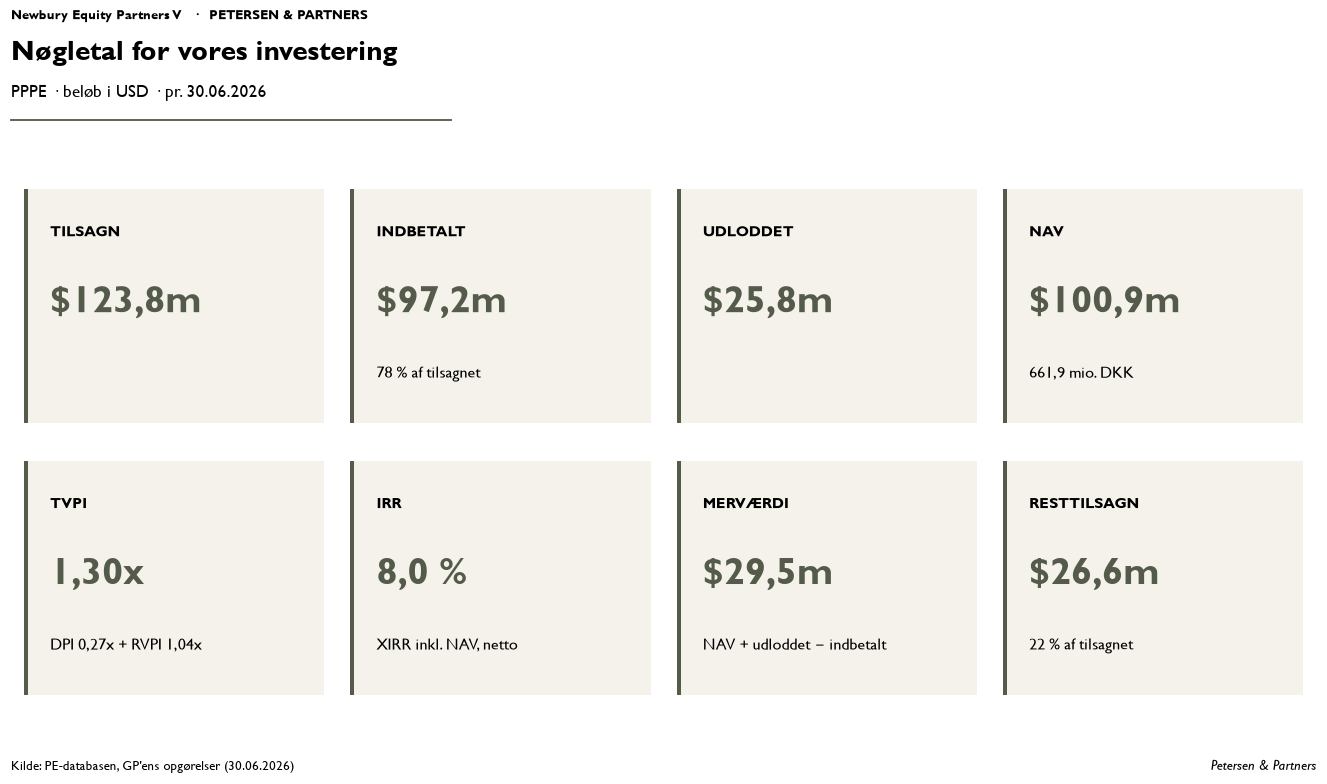

In [4]:
ob.graf_noegletal()

## 2. Kapitalforløb

gemt: charts\nep5_overblik_kapitalforloeb.png  (3200 x 1800 px · 16:9)


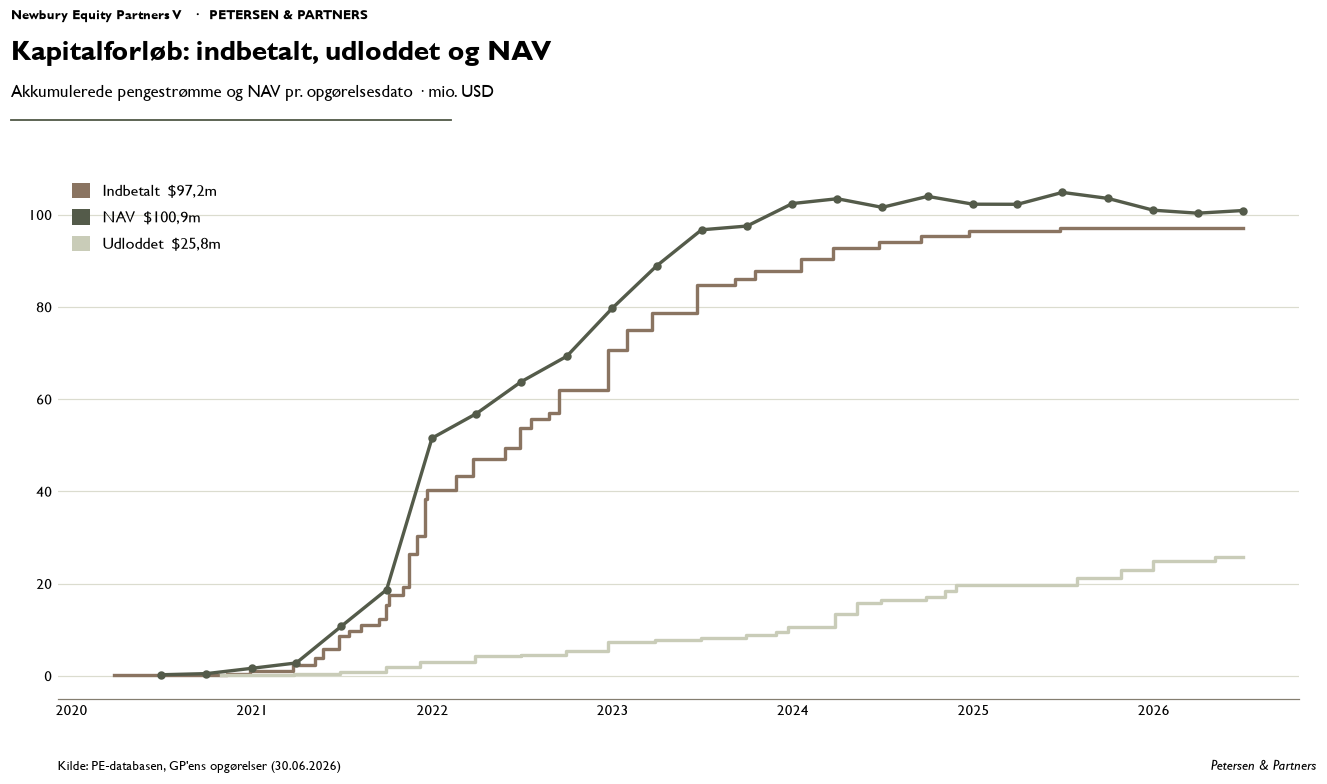

In [5]:
ob.graf_kapitalforloeb()

gemt: charts\nep5_overblik_pengestroemme.png  (3200 x 1800 px · 16:9)


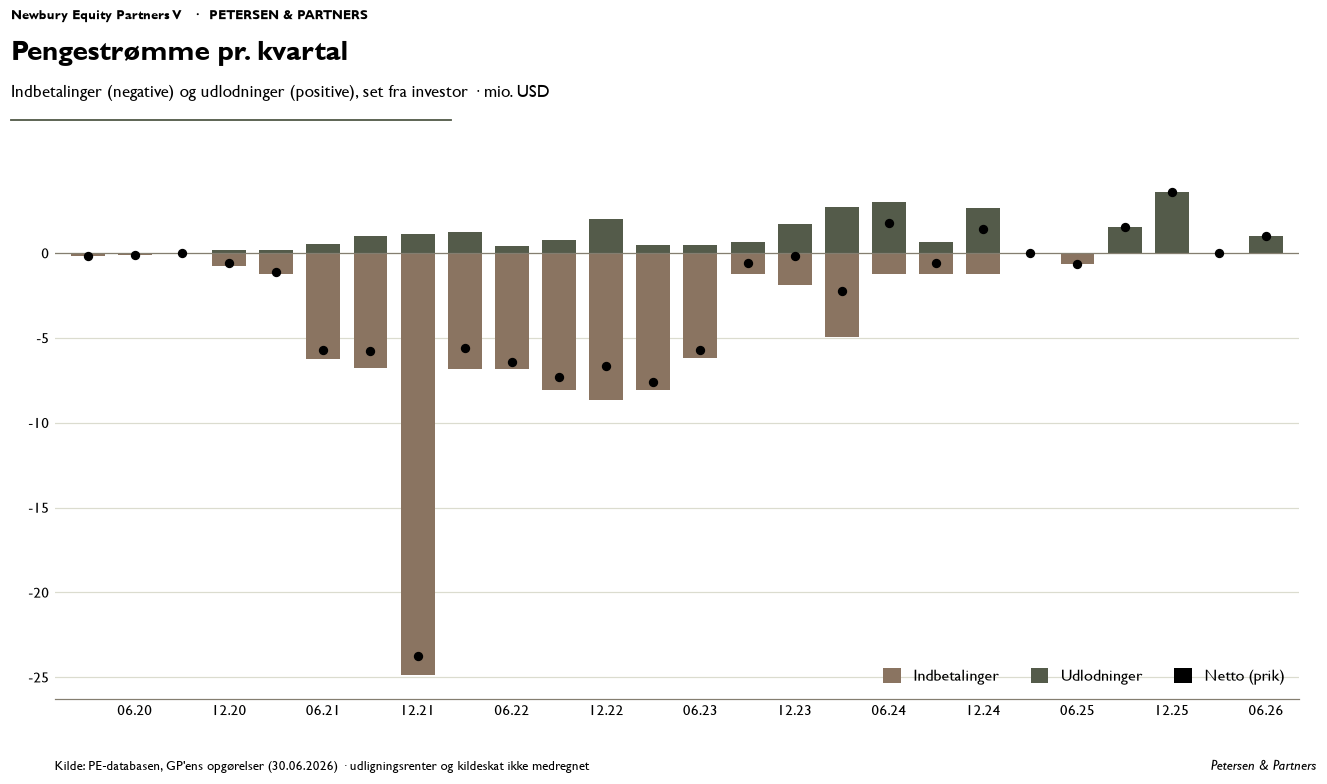

In [6]:
ob.graf_pengestroemme()

## 3. Afkast

TVPI opdelt i DPI og RVPI, J-kurven og IRR over tid.

gemt: charts\nep5_overblik_tvpi.png  (3200 x 1800 px · 16:9)


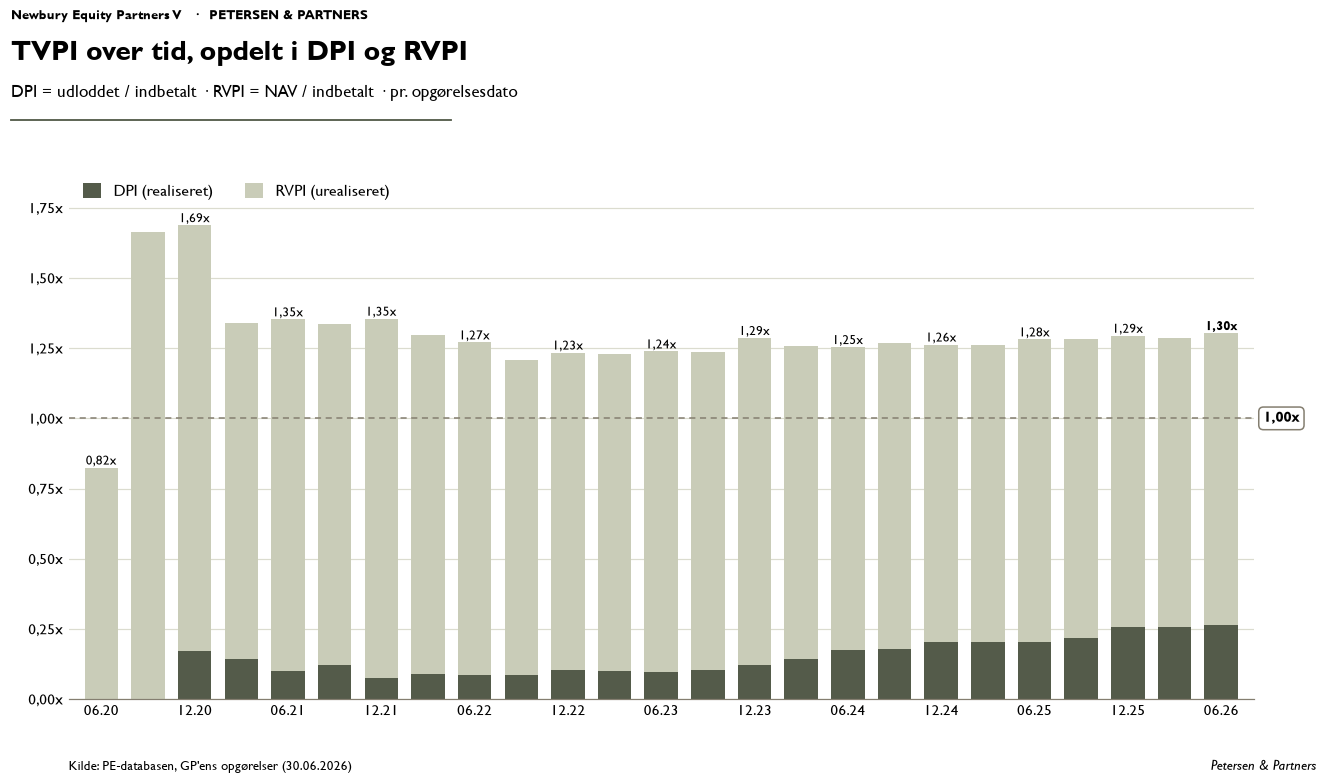

In [7]:
ob.graf_tvpi()

gemt: charts\nep5_overblik_jkurve.png  (3200 x 1800 px · 16:9)


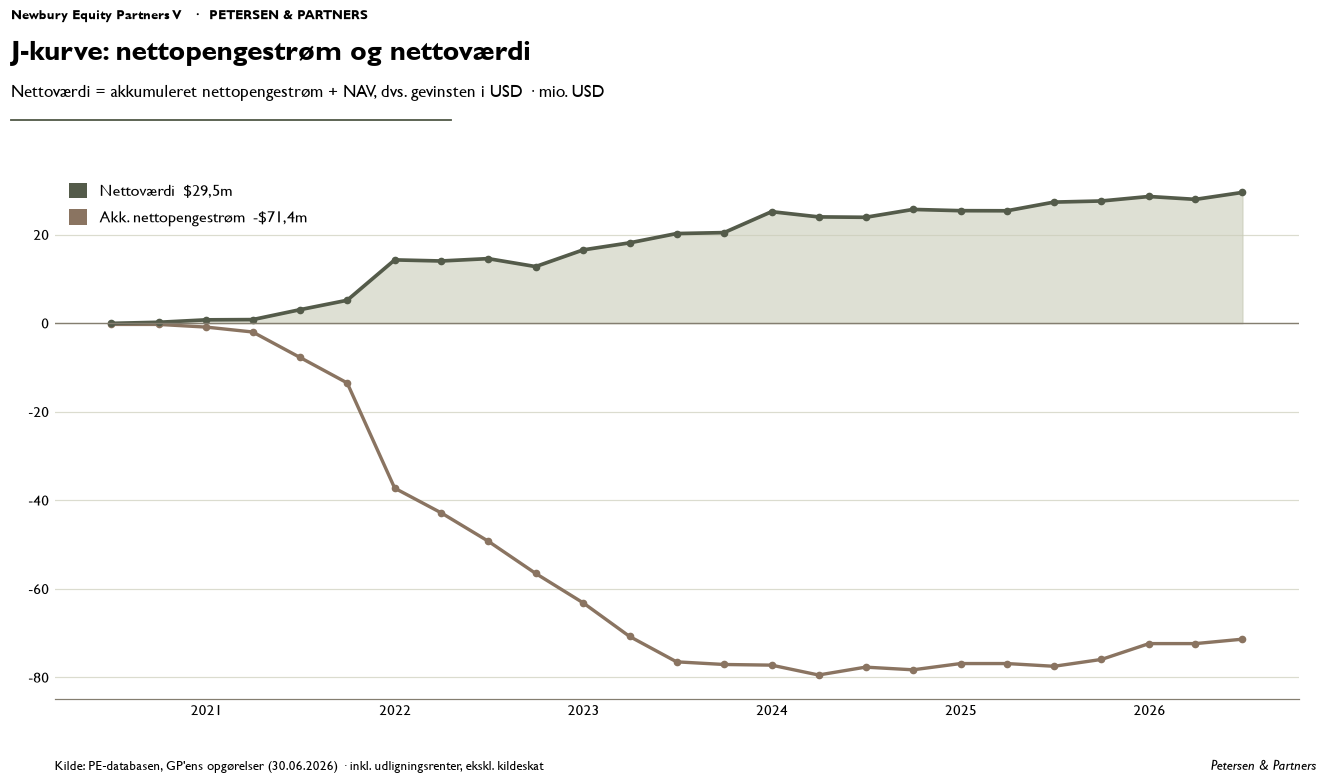

In [8]:
ob.graf_jkurve()

gemt: charts\nep5_overblik_irr.png  (3200 x 1800 px · 16:9)


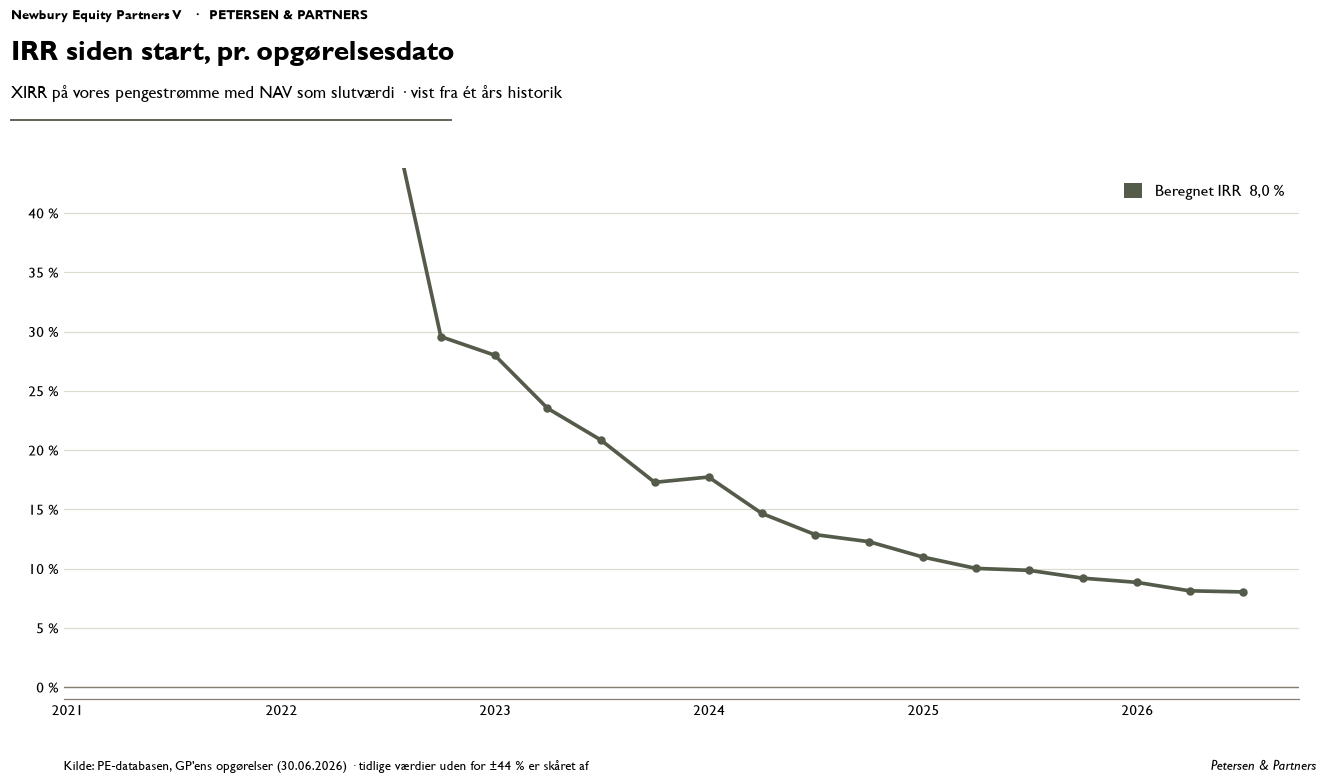

In [9]:
ob.graf_irr()

## 4. NAV-bro

Hvad har flyttet vores NAV: ind- og udbetalinger, resultat, honorar og carried interest, som GP'en
selv opgør det.

gemt: charts\nep5_overblik_nav_bro.png  (3200 x 1800 px · 16:9)


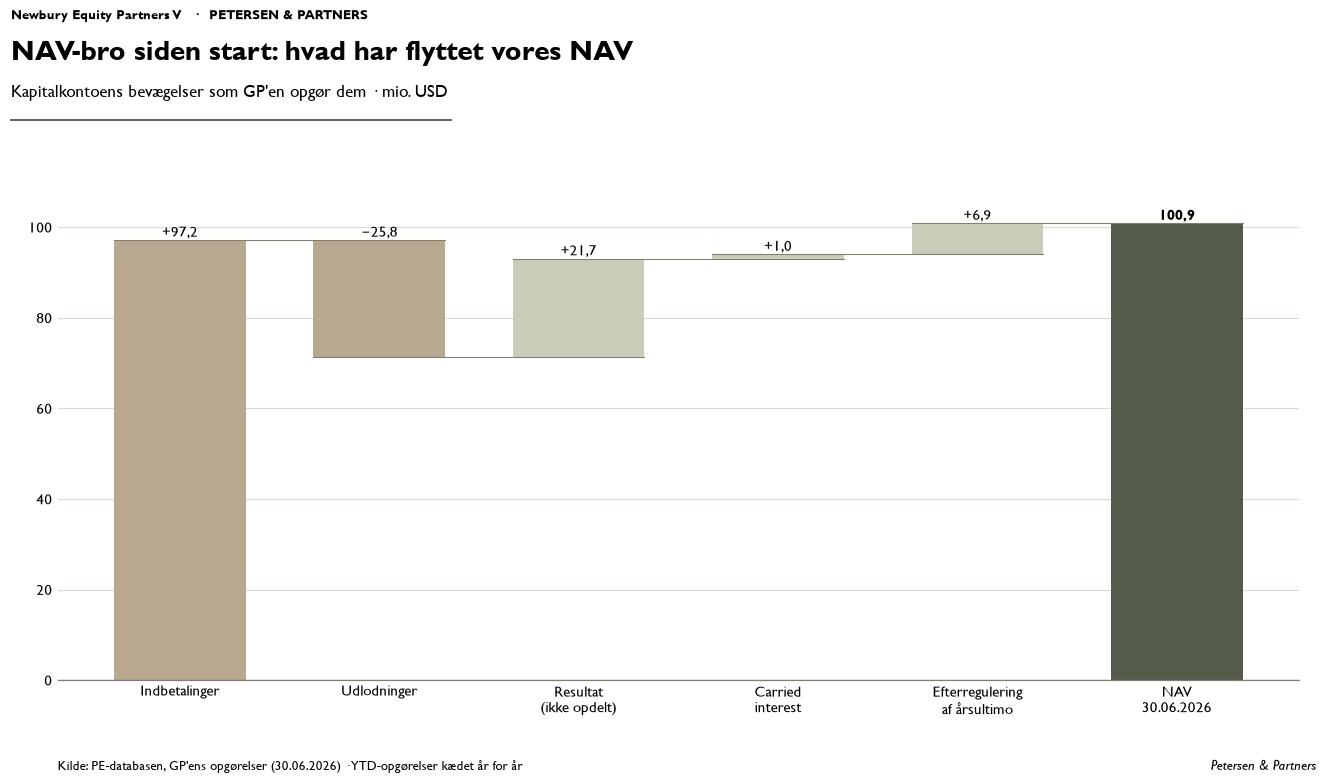

In [10]:
ob.graf_nav_bro()

# Del 2: Hele fonden (fondsniveau)

GP'ens tal for alle investorer under ét. De lægges aldrig sammen med tallene i del 1.

gemt: charts\nep5_overblik_fond_noegletal.png  (3200 x 1800 px · 16:9)


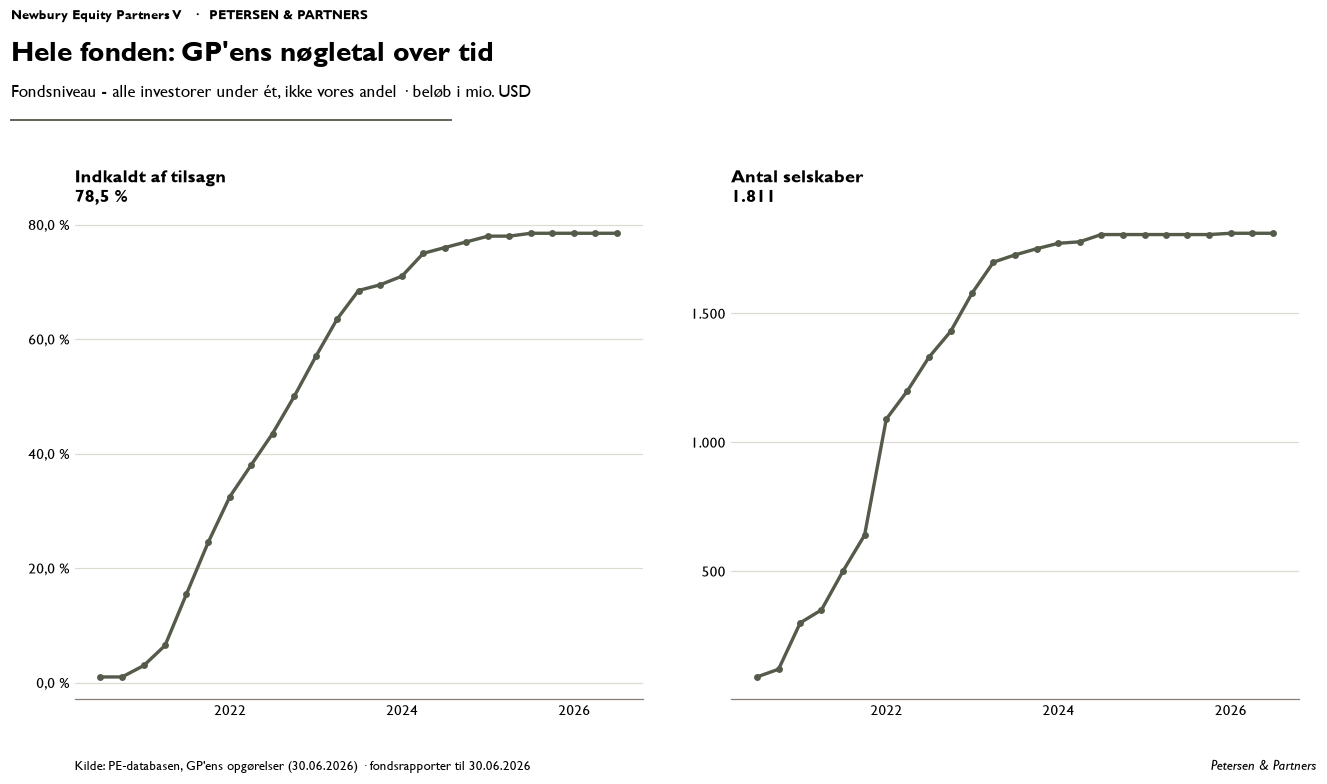

In [11]:
ob.graf_fond_noegletal()

gemt: charts\nep5_overblik_fond_beholdninger.png  (3200 x 1800 px · 16:9)


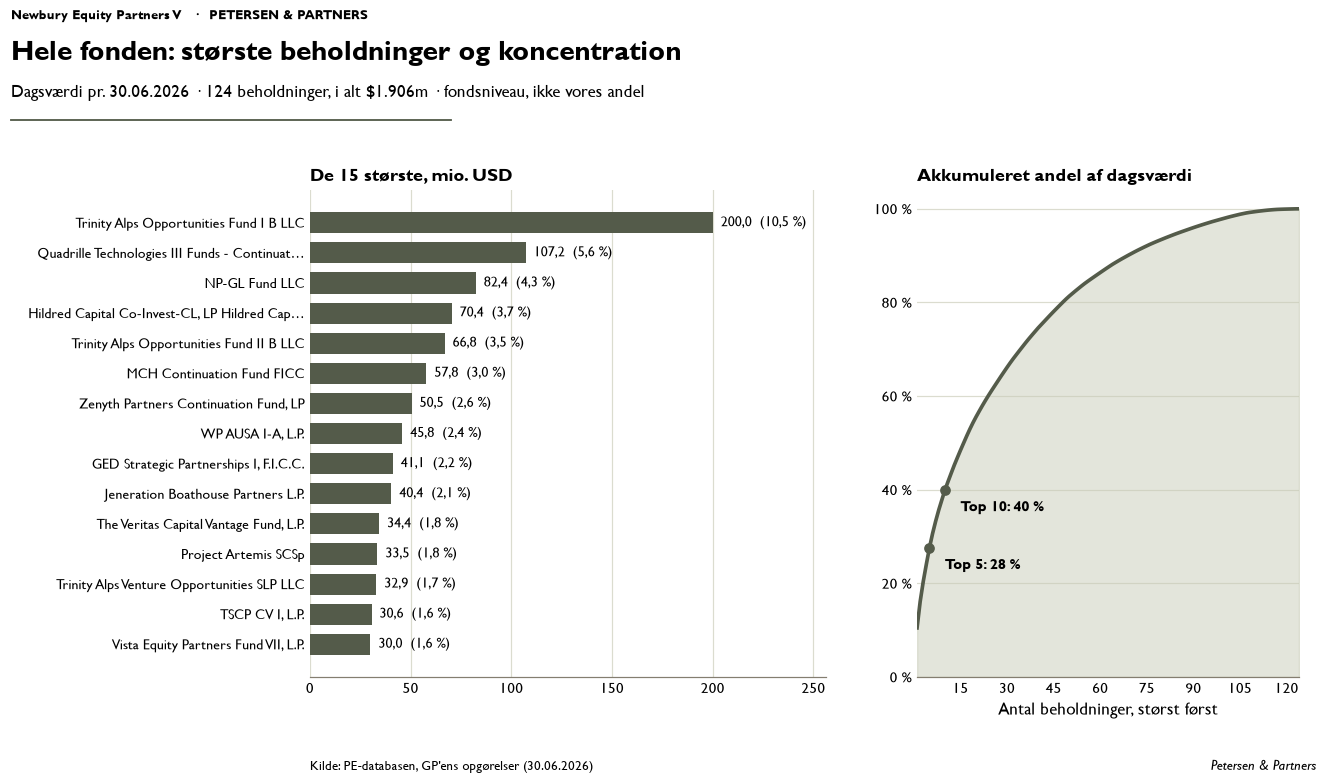

In [12]:
ob.graf_fond_beholdninger()

# Tabeller

gemt: charts\nep5_overblik_tabel_noegletal.png  (3200 x 1800 px · 16:9)


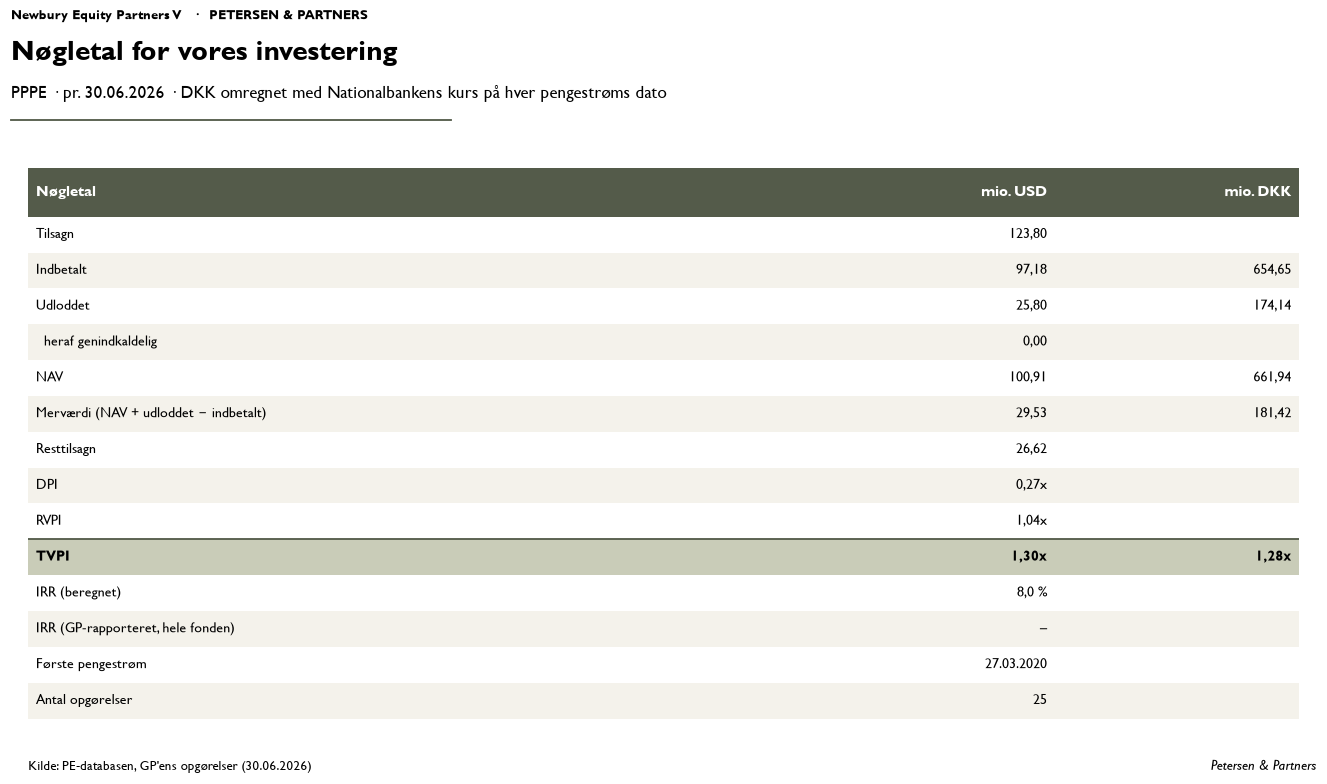

In [13]:
ob.tabel_noegletal()

gemt: charts\nep5_overblik_tabel_kvartaler_side1.png  (3200 x 1800 px · 16:9)


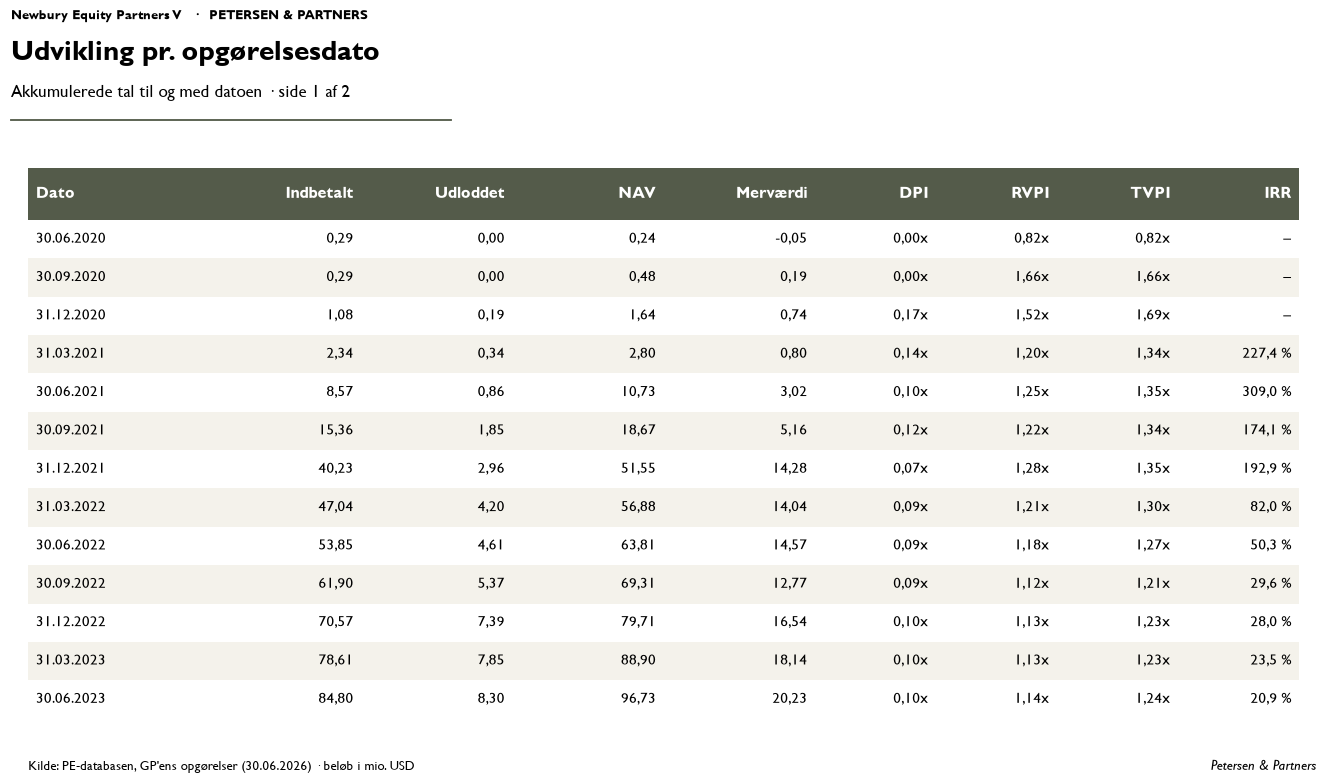

gemt: charts\nep5_overblik_tabel_kvartaler_side2.png  (3200 x 1800 px · 16:9)


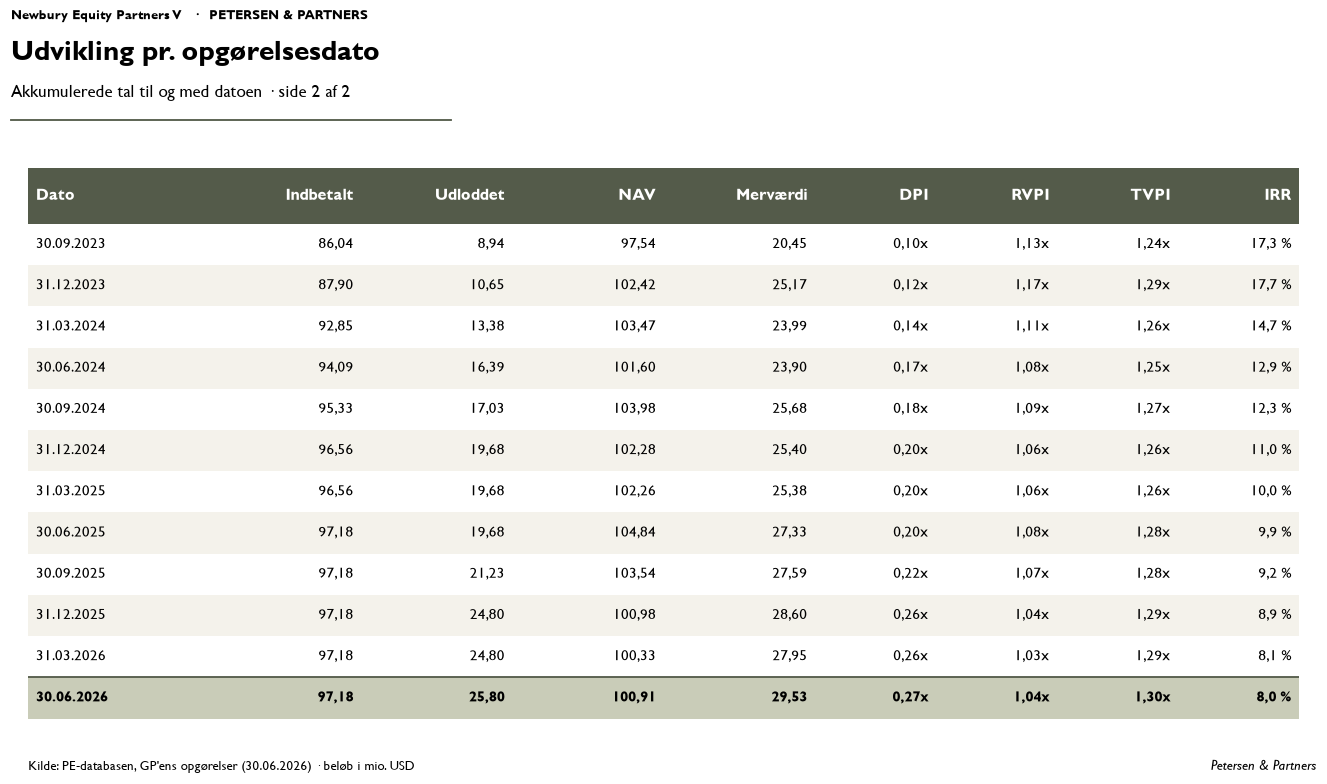

In [14]:
ob.tabel_kvartaler()

gemt: charts\nep5_overblik_tabel_pengestroemme_side1.png  (3200 x 1800 px · 16:9)


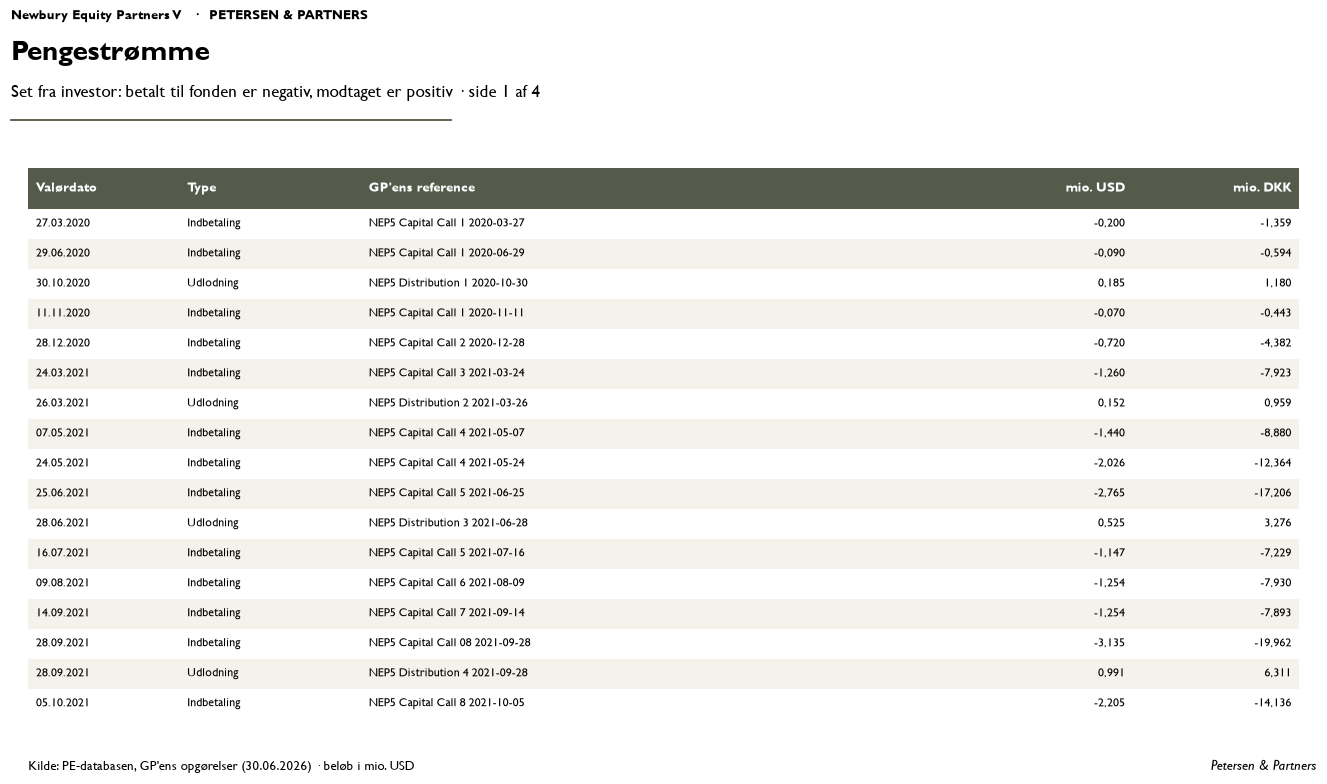

gemt: charts\nep5_overblik_tabel_pengestroemme_side2.png  (3200 x 1800 px · 16:9)


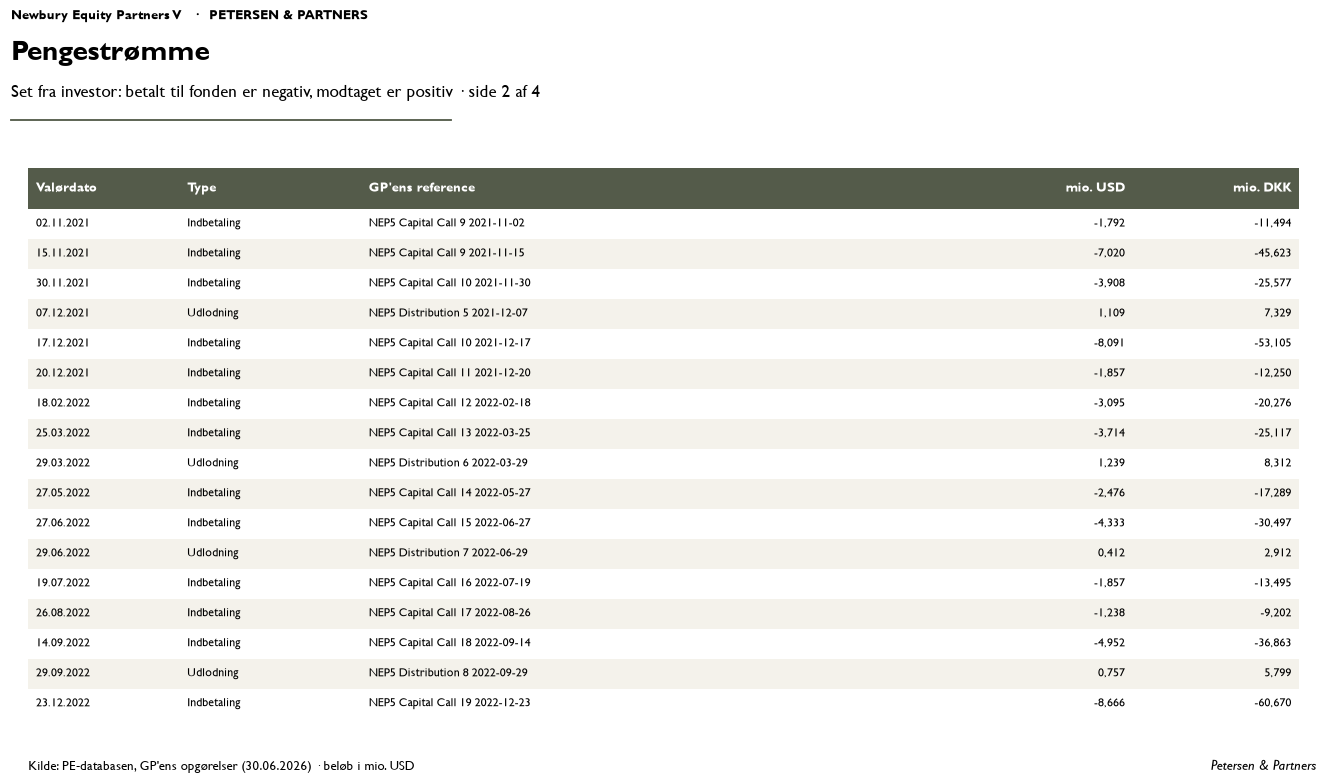

gemt: charts\nep5_overblik_tabel_pengestroemme_side3.png  (3200 x 1800 px · 16:9)


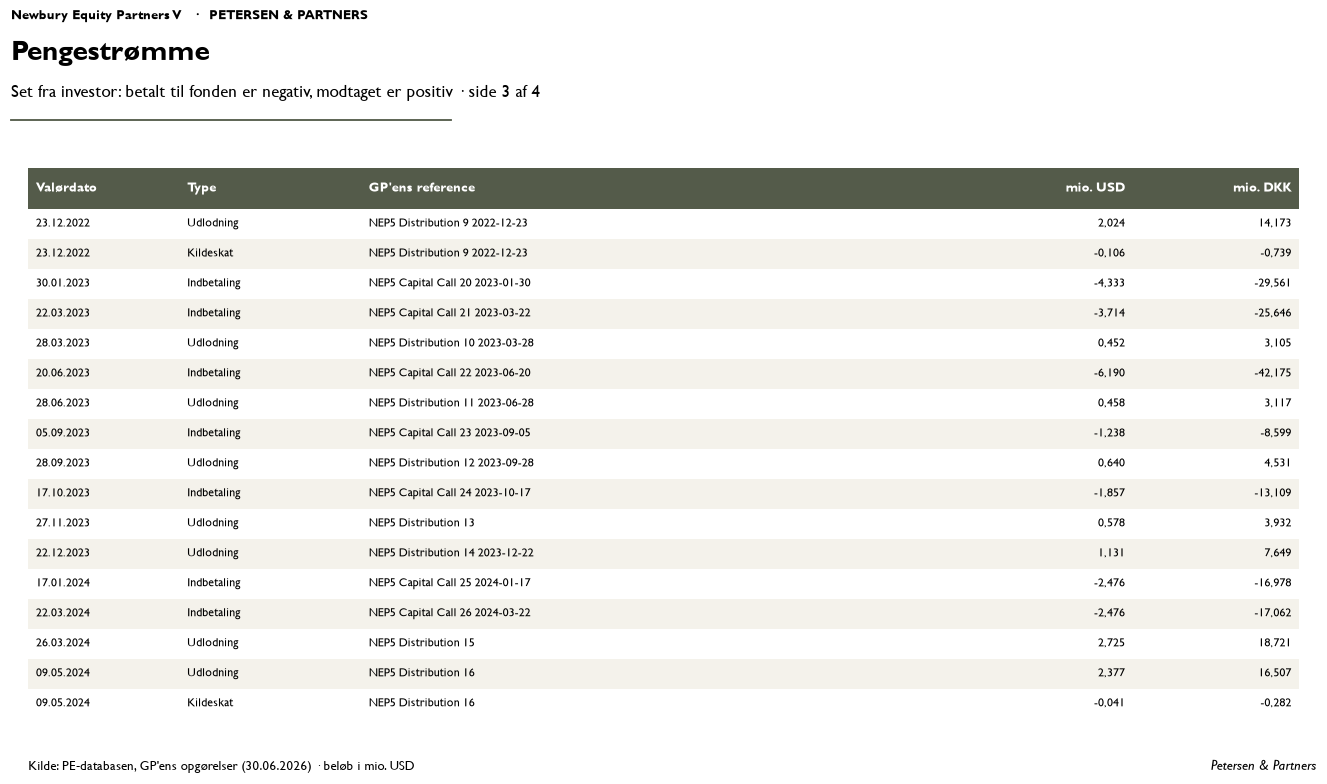

gemt: charts\nep5_overblik_tabel_pengestroemme_side4.png  (3200 x 1800 px · 16:9)


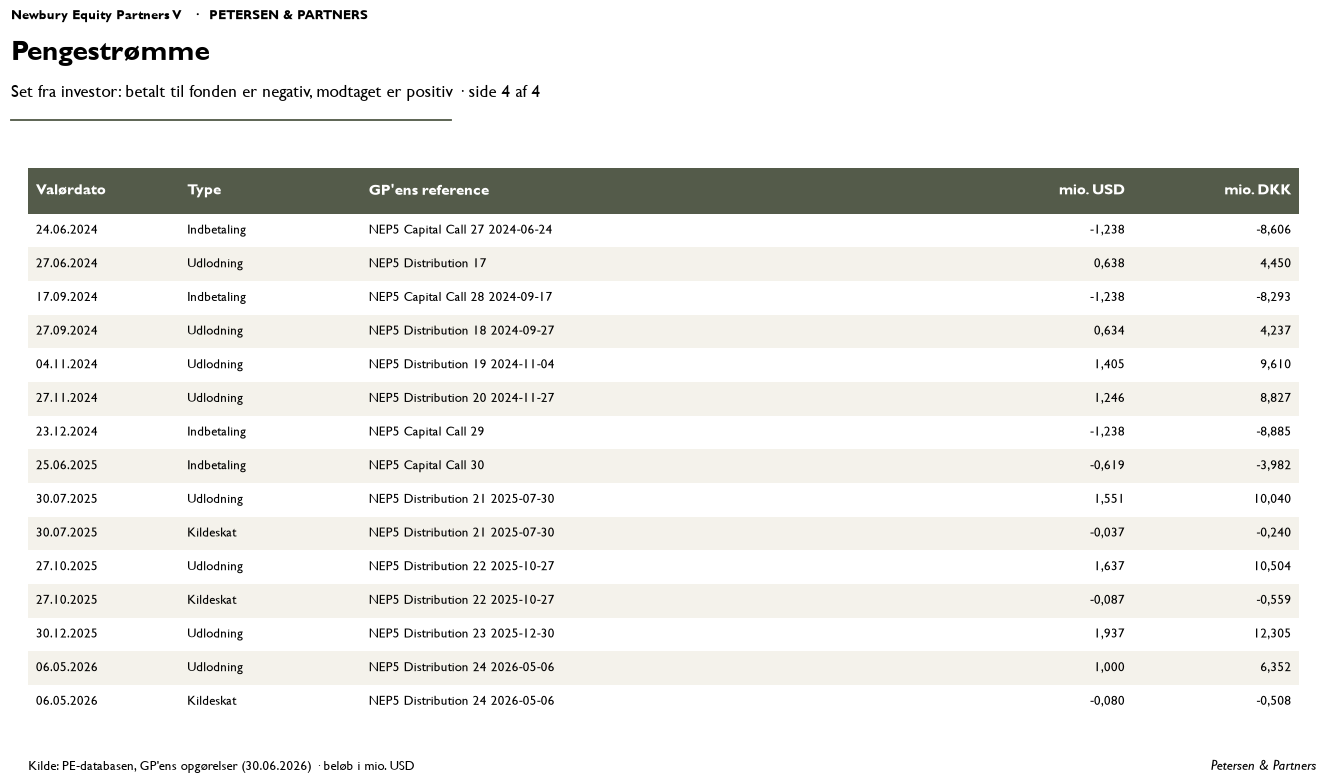

In [15]:
ob.tabel_pengestroemme()

# Eksport

Excel med alle tabellerne bag graferne, og ét deck på PPIM-masteren.

In [16]:
ob.excel()

gemt: exports\nep5_overblik_30062026.xlsx  (7 ark)


WindowsPath('exports/nep5_overblik_30062026.xlsx')

In [17]:
ob.deck()

gemt: exports\nep5_overblik_30062026.pptx  (27 slides)


WindowsPath('exports/nep5_overblik_30062026.pptx')